# Create partial results plot

Produces a grouped bar chart from the latest intermediate/final results JSON and saves it to PNG.

In [2]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Locate latest results file (intermediate preferred)
p = Path('.')
files = sorted(p.glob('results_multimodel_intermediate_*.json'))
if not files:
    files = sorted(p.glob('results_multimodel_final_*.json'))
if not files:
    raise FileNotFoundError('No results file found (expected pattern results_multimodel_intermediate_*.json or results_multimodel_final_*.json)')
latest = files[-1]
print(f'Loading results from: {latest}')
with open(latest, 'r') as f:
    all_results = json.load(f)

Loading results from: results_multimodel_intermediate_20260218_152421.json


In [4]:
# Flatten results into a DataFrame
rows = []
for model_name, ks in all_results.items():
    for k_label, methods in ks.items():
        try:
            k = int(k_label.split('=')[1])
        except Exception:
            k = 0
        for method, res in methods.items():
            rows.append({
                'model': model_name,
                'k': k,
                'method': method,
                'accuracy': res.get('accuracy', 0),
                'correct': res.get('correct_count', res.get('correct', 0)),
                'total': res.get('total', 0)
            })
viz_df = pd.DataFrame(rows)
if viz_df.empty:
    raise ValueError('No result rows found in the file')
viz_df.head()

,model,k,method,accuracy,correct,total
0,Mistral-7B-Instruct,10,abstract,97.435897,38,39
1,Mistral-7B-Instruct,10,no_context,69.230769,27,39
2,Mistral-7B-Instruct,10,faiss,38.461538,15,39
3,Mistral-7B-Instruct,10,mmr,35.897436,14,39
4,Mistral-7B-Instruct,10,bm25,41.025641,16,39


Plot saved to results_partial_plot.png (from results_multimodel_intermediate_20260218_152421.json)


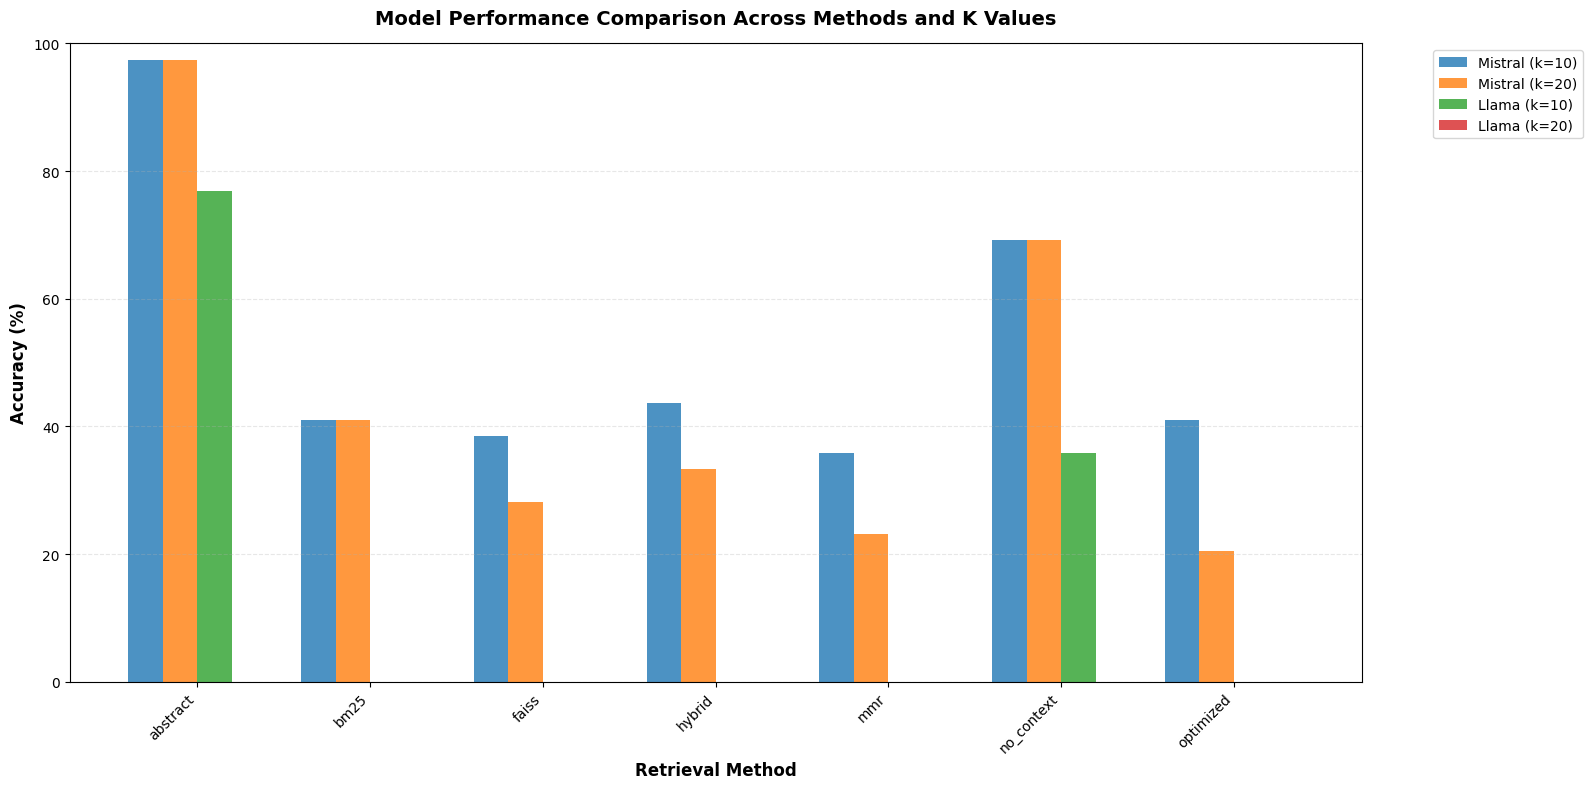

In [5]:
# Grouped bar chart: accuracy by method for each model/k (colors/order matched to 23b)
methods = sorted(viz_df['method'].unique())
# Determine model order: prefer Mistral then Llama if present
unique_models = list(viz_df['model'].unique())
preferred = []
for short in ['mistral', 'llama']:
    for m in unique_models:
        if short in m.lower() and m not in preferred:
            preferred.append(m)
# append any remaining models (in original order)
for m in unique_models:
    if m not in preferred:
        preferred.append(m)
models = preferred
# Ensure k ordering: prefer 10 then 20
k_values = sorted(viz_df['k'].unique())
k_values = [k for k in [10, 20] if k in k_values] + [k for k in k_values if k not in [10, 20]]

fig, ax = plt.subplots(figsize=(16, 8))
x = np.arange(len(methods))
# Use same width and default color ordering as original notebook (matplotlib default cycle)
width = 0.2
# Matplotlib default color cycle hex equivalents (blue, orange, green, red)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, model in enumerate(models):
    for j, k in enumerate(k_values):
        idx = i * len(k_values) + j
        color = colors[idx % len(colors)]
        # Keep same offset calculation/order as 23b (model-major, then k)
        offset = width * (i * len(k_values) + j - 1.5)
        data = viz_df[(viz_df['model'] == model) & (viz_df['k'] == k)]
        accuracies = [
            data[data['method'] == m]['accuracy'].values[0] if len(data[data['method'] == m]) > 0 else 0
            for m in methods
        ]
        label = f"{model.split('-')[0]} (k={k})"
        ax.bar(x + offset, accuracies, width, label=label, color=color, alpha=0.8)
ax.set_xlabel('Retrieval Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison Across Methods and K Values', fontsize=14, fontweight='bold', pad=14)
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 100)
plt.tight_layout()
out_png = 'results_partial_plot.png'
plt.savefig(out_png, dpi=200)
print(f'Plot saved to {out_png} (from {latest})')
plt.show()

In [7]:
# Show examples where no-context got it right but FAISS and MMR failed (Mistral, k=10)
try:
    # Find model key for Mistral (case-insensitive match)
    model_key = next(m for m in all_results.keys() if 'mistral' in m.lower())
except StopIteration:
    print('No Mistral model found in results keys:', list(all_results.keys()))
    model_key = None

examples = []
if model_key:
    k_label = 'k=10'
    if k_label not in all_results.get(model_key, {}):
        print(f"{k_label} not found for model {model_key}. Available keys:", list(all_results.get(model_key, {}).keys()))
    else:
        bucket = all_results[model_key][k_label]
        no_ctx = bucket.get('no_context', {}).get('detailed_results', [])
        faiss = bucket.get('faiss', {}).get('detailed_results', [])
        mmr = bucket.get('mmr', {}).get('detailed_results', [])

        n = min(len(no_ctx), len(faiss) if faiss else len(no_ctx), len(mmr) if mmr else len(no_ctx))
        for i in range(n):
            no_r = no_ctx[i] if i < len(no_ctx) else {}
            f_r = faiss[i] if i < len(faiss) else {}
            m_r = mmr[i] if i < len(mmr) else {}
            if no_r.get('is_correct') and not f_r.get('is_correct') and not m_r.get('is_correct'):
                examples.append((i, no_r, f_r, m_r))
            if len(examples) >= 10:
                break

        print(f"Found {len(examples)} examples where no_context correct but FAISS/MMR incorrect (showing up to 10):")
        for idx, no_r, f_r, m_r in examples:
            print('\n' + '-'*80)
            q = no_r.get('query') or f_r.get('query') or m_r.get('query') or '<question missing>'
            correct = no_r.get('correct_answer') or f_r.get('correct_answer') or m_r.get('correct_answer') or '<correct missing>'
            print(f"Index: {idx} | Question: {q}")
            print(f"Correct answer: {correct}")
            print('\n-- NO CONTEXT (correct) --')
            print('Model answer:', no_r.get('model_answer'))
            print('Explanation:', no_r.get('explanation'))
            print('Full response snippet:', (no_r.get('full_response') or '')[:400].replace('\n',' '))
            print('\n-- FAISS (incorrect) --')
            print('Model answer:', f_r.get('model_answer'))
            print('Explanation:', f_r.get('explanation'))
            print('Full response snippet:', (f_r.get('full_response') or '')[:400].replace('\n',' '))
            print('\n-- MMR (incorrect) --')
            print('Model answer:', m_r.get('model_answer'))
            print('Explanation:', m_r.get('explanation'))
            print('Full response snippet:', (m_r.get('full_response') or '')[:400].replace('\n',' '))
        if not examples:
            print('No matching examples found with the given criteria.')
else:
    print('Skipping example extraction because model_key not found.')

# Save examples to JSON and CSV for later inspection
if examples:
    from datetime import datetime
    import pandas as pd
    rows_out = []
    for idx, no_r, f_r, m_r in examples:
        q = no_r.get('query') or f_r.get('query') or m_r.get('query') or ''
        correct = no_r.get('correct_answer') or f_r.get('correct_answer') or m_r.get('correct_answer') or ''
        rows_out.append({
            'index': idx,
            'question': q,
            'correct_answer': correct,
            'no_context_answer': no_r.get('model_answer'),
            'no_context_explanation': no_r.get('explanation'),
            'no_context_snippet': (no_r.get('full_response') or '')[:1000],
            'faiss_answer': f_r.get('model_answer'),
            'faiss_explanation': f_r.get('explanation'),
            'faiss_snippet': (f_r.get('full_response') or '')[:1000],
            'mmr_answer': m_r.get('model_answer'),
            'mmr_explanation': m_r.get('explanation'),
            'mmr_snippet': (m_r.get('full_response') or '')[:1000]
        })
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    json_file = f'noctx_vs_faiss_mmr_examples_{ts}.json'
    csv_file = f'noctx_vs_faiss_mmr_examples_{ts}.csv'
    with open(json_file, 'w', encoding='utf-8') as jf:
        json.dump(rows_out, jf, ensure_ascii=False, indent=2)
    pd.DataFrame(rows_out).to_csv(csv_file, index=False)
    print(f'Saved {len(rows_out)} examples to {json_file} and {csv_file}')
else:
    print('No examples to save.')


Found 10 examples where no_context correct but FAISS/MMR incorrect (showing up to 10):

--------------------------------------------------------------------------------
Index: 0 | Question: What is the purpose of combining H-ZSM-5 and mordenite in a bi-functional zeolite membrane?
A) To enhance the mechanical strength of the membrane.
B) To increase the thermal stability of the membrane.
C) To combine catalytic activity with selective separation properties.
D) To improve the electrical conductivity of the membrane.
E) None of the above.
Correct answer: C

-- NO CONTEXT (correct) --
Model answer: C
Explanation: To combine catalytic activity with selective separation properties.
Full response snippet: Human:  You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer.  Provide your answer in the following format EXACTLY: Answer: [LETTER] - [One sentence explanation]  For example: Answer: B - The synthesis temperature was increased to improve c